# Corrected LSTM — Fair Evaluation / 修正版 LSTM——公平评估

The original LSTM (`01_lstm_reimplementation.ipynb`) achieved 99.1% accuracy, but EDA revealed two leakage sources:
- `subject` column: perfectly separates fake from real (100% accuracy alone)
- Reuters byline in text: present in 99.2% of real news, 0% of fake news

This notebook retrains the same LSTM architecture with **clean input only**: `title + text`, with `subject` and `date` removed. The goal is to measure how well the model performs when it cannot exploit source-level shortcuts — and to provide a fair baseline for comparison with DistilBERT.

---

原始 LSTM（`01_lstm_reimplementation.ipynb`）达到了 99.1% 的准确率，但 EDA 发现了两个泄露来源：
- `subject` 列：单独使用就能 100% 区分真假新闻
- 正文中的 Reuters 署名：出现在 99.2% 的真新闻中，假新闻中为 0%

本 notebook 使用完全相同的 LSTM 结构重新训练，但输入改为**干净的 `title + text`**，去掉 `subject` 和 `date`。目标是在模型无法利用来源捷径的情况下，测量其真实的语言理解能力，并为后续与 DistilBERT 的比较提供公平的基准。

## 1. Imports

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

os.makedirs('../results', exist_ok=True)
print('TensorFlow:', tf.__version__)

TensorFlow: 2.16.2


## 2. Load Data — Clean Input Only

与原始 LSTM 的关键区别：输入改为 `title + text` 拼接，去掉 `subject` 和 `date` 列，消除泄露来源。

Key difference from the original LSTM: input is now `title + text` concatenated. `subject` and `date` are excluded to remove leakage sources.

In [22]:
import html as html_module

fake = pd.read_csv('../data/raw/Fake.csv')
true = pd.read_csv('../data/raw/True.csv')

fake['label'] = 0
true['label'] = 1

df = pd.concat([fake, true]).sample(frac=1, random_state=42).reset_index(drop=True)

# 删除泄露列subject和date
# Explicitly drop leakage columns
df = df.drop(columns=['subject', 'date'])

# Fix 1: Remove Reuters byline at start, handles multi-word city names
# 去掉开头的 Reuters 署名，支持多词城市名
df['text'] = df['text'].str.replace(r'[\w\s]+\(Reuters\)\s*-?\s*', '', regex=True)

# Fix 2: Remove remaining Reuters mentions anywhere in the body
# 去掉正文中其他地方出现的 Reuters 字样
df['text'] = df['text'].str.replace(r'Reuters', '', regex=False)

# Fix 3: Remove residual all-caps city datelines at start of text
# 去掉残留的开头全大写城市署名
df['text'] = df['text'].str.replace(r'^\s*[A-Z][A-Z\s\.]+\s*-\s*', '', regex=True)

# Fix 4: Remove other wire service bylines (AP, AFP, UPI)
# 去掉其他通讯社署名
df['text'] = df['text'].str.replace(r'[\w\s]+\((AP|AFP|UPI)\)\s*-?\s*', '', regex=True)
df['text'] = df['text'].str.replace(r'\b(AP|AFP|UPI)\b', '', regex=True)

# Fix 5: Remove URLs
# 去掉 URL 链接
df['text'] = df['text'].str.replace(r'http\S+|www\.\S+', '', regex=True)

# Fix 6: Remove social media handles
# 去掉社交媒体 @用户名
df['text'] = df['text'].str.replace(r'@\w+', '', regex=True)

# Fix 7: Unescape HTML entities and remove non-ASCII characters
# 解码 HTML 实体字符，去掉非 ASCII 字符
df['text'] = df['text'].apply(html_module.unescape)
df['text'] = df['text'].str.replace(r'[^\x00-\x7F]+', ' ', regex=True)

# Fix 8: Normalise whitespace
# 统一处理多余空白
df['text'] = df['text'].str.strip()
df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True)

# 拼接 title 和 text 作为模型输入
# Concatenate title and text as model input
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

# Fix 9: Remove articles that became too short after cleaning (< 10 words)
# 去掉清洗后内容过短的文章（少于 10 词）
before = len(df)
df = df[df['content'].str.split().str.len() > 10].reset_index(drop=True)
after = len(df)

print(f'Total after cleaning: {after:,} rows ({before - after} removed as too short)')
print('Columns dropped: subject, date')
print('Cleaning applied:')
print('  [1-3] Reuters byline, mentions, city datelines removed')
print('  [4]   AP / AFP / UPI bylines removed')
print('  [5]   URLs removed')
print('  [6]   Social media handles removed')
print('  [7]   HTML entities decoded, non-ASCII removed')
print('  [8]   Whitespace normalised')
print('  [9]   Articles with fewer than 10 words removed')
df[['content', 'label']].head(3)

Total after cleaning: 44,804 rows (94 removed as too short)
Columns dropped: subject, date
Cleaning applied:
  [1-3] Reuters byline, mentions, city datelines removed
  [4]   AP / AFP / UPI bylines removed
  [5]   URLs removed
  [6]   Social media handles removed
  [7]   HTML entities decoded, non-ASCII removed
  [8]   Whitespace normalised
  [9]   Articles with fewer than 10 words removed


,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1


共进行了九步文本清洗，目标是消除所有可识别的来源层面泄露信号。首先删除了 `subject` 和 `date` 列，这两列直接暴露了文章来源，与新闻内容本身无关。接着清除了与 Reuters 相关的所有标记：开头的城市署名（如 `NEW YORK (Reuters) -`）、正文中其他出现的 Reuters 字样、以及去掉署名后残留的全大写城市名（如 `WASHINGTON -`）。随后清除了 AP、AFP、UPI 等其他通讯社的同类格式署名。接着去掉了 URL 链接和社交媒体 @用户名——这两类在假新闻中更为常见，属于隐性的来源信号。最后对爬取数据中残留的 HTML 实体字符和非 ASCII 字符进行了解码和清理，并统一处理了多余空白。清洗完成后过滤掉内容少于 10 词的文章，防止近空序列进入训练。

Nine cleaning steps were applied to remove all identifiable source-level leakage signals. First, the `subject` and `date` columns were dropped as they directly expose the article source rather than its content. Reuters-related markers were then removed: the byline pattern (e.g. `NEW YORK (Reuters) -`), any remaining Reuters mentions in the body, and residual all-caps city datelines. Other wire service bylines (AP, AFP, UPI) were then stripped. URLs and social media handles were removed as implicit source signals more common in fake news. HTML entities and non-ASCII artifacts from web scraping were decoded and cleaned, followed by whitespace normalisation. Finally, articles reduced to fewer than 10 words after cleaning were filtered out to prevent near-empty sequences from entering training. The only remaining bias is Reuters' **writing style**, which will be addressed in error analysis.

## 3. Text Preprocessing / 文本预处理

按照原论文的流程，文本预处理分三步：划分训练测试集 → Tokenizer 建立词表 → 将文本转换为数字序列并统一长度（padding）。输入使用 `content`（title + text），不含 `subject` 和 `date`。

Following the original paper pipeline: train/test split → Tokenizer vocabulary construction → convert text to padded integer sequences. Input is `content` (title + text only).

In [23]:
# 划分训练测试集 80/20，与原论文一致
# Train/test split 80/20, matching original paper
X = df['content']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Train: 35,843  |  Test: 8,961


In [24]:
# Tokenizer：保留前 5000 高频词，与原论文一致
# Tokenizer: top 5,000 words, matching original paper
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

vocab_size = len(tokenizer.word_index)
print(f'Full vocabulary size: {vocab_size:,}')
print(f'Using top 5,000 words (as per original paper)')

Full vocabulary size: 113,223
Using top 5,000 words (as per original paper)


In [25]:
# 转为数字序列并补齐至长度 200，与原论文一致
# Convert to sequences and pad to length 200, matching original paper
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=200)
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=200)

print(f'X_train shape: {X_train_seq.shape}')
print(f'X_test shape:  {X_test_seq.shape}')

X_train shape: (35843, 200)
X_test shape:  (8961, 200)


预处理完成。每篇文章被表示为长度 200 的整数数组，不足补零，超过截断。与原始 LSTM 的唯一区别是输入内容：这里是 `title + text`，原始版本是 `text`。

Preprocessing complete. Each article is a zero-padded integer sequence of length 200. The only difference from the original LSTM is the input: here we use `title + text`; the original used `text` only.

## 4. Build LSTM Model / 搭建模型

模型结构与原论文完全一致，不做任何改动。控制变量：唯一的差异来自输入数据，而非模型本身。

Model architecture is identical to the original paper — no changes. This is a controlled experiment: any difference in results comes from the input data, not the model.

In [26]:
model = Sequential([
    # 词嵌入层：把每个词的编号映射成 100 维向量
    # Embedding: maps each word index to a 100-dimensional vector
    Embedding(input_dim=5000, output_dim=100, input_length=200),

    # 双向 LSTM 层：同时从左到右和从右到左读取序列，捕捉更完整的上下文
    # Bidirectional LSTM: reads the sequence in both directions for richer context
    Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)),

    # 全连接层：提取更高层特征
    # Dense: extracts higher-level features
    Dense(64, activation='relu'),

    # Dropout：防止过拟合
    # Dropout: reduces overfitting
    Dropout(0.5),

    # 输出层：0~1 概率，>0.5 为真新闻
    # Output: probability score — >0.5 classified as real news
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/Users/sl1425/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**优化一：LSTM → Bidirectional LSTM**

原始论文使用的是单向 LSTM，每次只从左到右读取文章。这意味着模型在处理每个词时，只能看到它前面的内容，看不到后面的词。

Bidirectional LSTM 同时运行两个 LSTM：一个从左到右，一个从右到左，最后把两个方向的输出拼接在一起。这样模型在理解每个词的时候，既知道前文是什么，也知道后文是什么，对句子的理解更完整。

例如：`"He said the story was completely false"` 中，`false` 这个词的意义需要结合前面的 `completely` 和整个句子结构来理解，Bidirectional LSTM 能更好地捕捉这种关系。代价是参数量翻倍（两个方向各 128 个单元），训练时间也相应增加。

**Optimisation 1: LSTM → Bidirectional LSTM**

The original paper used a unidirectional LSTM that reads the article left-to-right only. At each word, the model only sees what came before it.

A Bidirectional LSTM runs two LSTMs simultaneously — one forward, one backward — and concatenates their outputs. This means the model understands each word in the context of both what precedes and what follows it, giving a richer representation of the text.

For example, in `"He said the story was completely false"`, the meaning of `false` is shaped by `completely` and the broader sentence structure. A Bidirectional LSTM captures this better. The trade-off is doubled parameters and longer training time.

## 5. Train Model / 训练模型

训练参数与原论文完全一致：10 个 epoch，batch size 64，20% 验证集。

Training parameters match the original paper exactly: 10 epochs, batch size 64, 20% validation split.

In [27]:
history = model.fit(
    X_train_seq, y_train,
    epochs=10,            # 原论文：10 轮 / original paper: 10 epochs
    batch_size=64,        # 原论文：每批 64 条 / original paper: batch size 64
    validation_split=0.2  # 20% 训练数据作为验证集 / 20% validation split
)

Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 138s 299ms/step - accuracy: 0.8744 - loss: 0.2651 - val_accuracy: 0.9675 - val_loss: 0.0954
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 129s 287ms/step - accuracy: 0.9740 - loss: 0.0768 - val_accuracy: 0.9748 - val_loss: 0.0750
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 160s 357ms/step - accuracy: 0.9812 - loss: 0.0585 - val_accuracy: 0.9729 - val_loss: 0.0933
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 161s 359ms/step - accuracy: 0.9762 - loss: 0.0709 - val_accuracy: 0.9742 - val_loss: 0.0827
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 156s 348ms/step - accuracy: 0.9876 - loss: 0.0379 - val_accuracy: 0.9753 - val_loss: 0.0754
Epoch 6/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 166s 370ms/step - accuracy: 0.9901 - loss: 0.0297 - val_accuracy: 0.9764 - val_loss: 0.0897
Epoch 7/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 161s 358ms/step - accuracy: 0.9930 - loss: 0.0240 - val_accuracy: 0.9759 - val_loss: 0.0863
Epoch 8/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 158s 352ms/step - accuracy: 0.9970 -

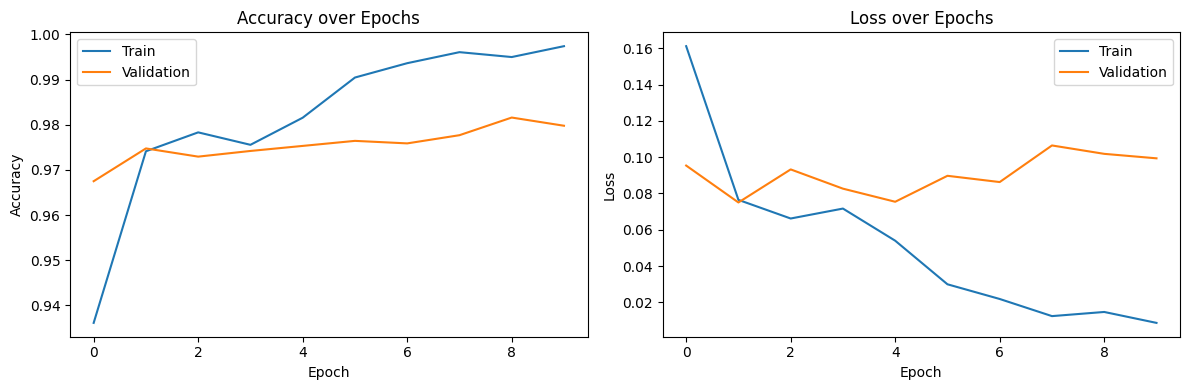

In [28]:
# 训练曲线：accuracy 和 loss 随 epoch 变化
# Training curves: accuracy and loss over epochs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/lstm_corrected_training_curves.png', dpi=150)
plt.show()